In [7]:
import pandas as pd
from pathlib import Path
df = pd.read_csv("reddit_wsb_cleaned.csv")
df.head(50).to_string(index=False)

'    id           timestamp       date                                                                                                                                                                                      title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

In [6]:
import pandas as pd
import numpy as np

# EDA Part 1: Summary statistics & descriptive insights

# 1.1 Basic overview: shape + quick samples
print("Dataset shape (rows, columns):", df.shape)

display(df.head(3))                      # first 3 rows (quick sanity check)
display(df.sample(3, random_state=42))   # random 3 rows (check consistency)

# 1.2 Column types + missingness + unique values
info_df = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "nunique": df.nunique()
}).sort_values("missing_pct", ascending=False)

print("\nColumn summary (sorted by missing percentage):")
display(info_df)

# 1.3 Descriptive stats for numeric columns (core numeric features)
num_cols = [
    "score", "comms_num",
    "score_log", "comms_num_log",
    "title_length",
    "hour",
    "score_log_zscore", "comms_num_log_zscore", "title_length_zscore", "hour_zscore",
    "score_log_minmax", "comms_num_log_minmax", "title_length_minmax", "hour_minmax"
]
# Keep only columns that exist in df (robust to different versions of the dataset)
num_cols = [c for c in num_cols if c in df.columns]

print("\nDescriptive statistics for numeric columns:")
display(df[num_cols].describe().T)

# 1.4 Frequency tables for categorical/binary columns
cat_cols = ["post_type", "post_type_lumped", "day_of_week", "has_body", "type_image", "type_text"]
cat_cols = [c for c in cat_cols if c in df.columns]

for c in cat_cols:
    print(f"\n=== Value counts for '{c}' (top 20, including NaN) ===")
    display(df[c].value_counts(dropna=False).head(20))


Dataset shape (rows, columns): (53187, 30)


,id,timestamp,date,title,body,url,title_clean,body_clean,title_nlp,score,...,score_log_zscore,score_log_minmax,comms_num_log_zscore,comms_num_log_minmax,title_length_zscore,title_length_minmax,hour_zscore,hour_minmax,type_image,type_text
0,l6ulcx,2021-01-28 21:37:41,2021-01-28,"It's not about the money, it's about sending a...",NaN,https://v.redd.it/6j75regs72e61,"it's not about the money, it's about sending a...",NaN,its not about the money its about sending a me...,55,...,0.147775,0.315450,-0.487343,0.170049,0.012993,0.196667,2.071716,0.913043,False,False
1,l6uibd,2021-01-28 21:32:10,2021-01-28,Math Professor Scott Steiner says the numbers ...,NaN,https://v.redd.it/ah50lyny62e61,math professor scott steiner says the numbers ...,NaN,math professor scott steiner says the numbers ...,110,...,0.412909,0.369067,0.157782,0.277723,0.470889,0.266667,2.071716,0.913043,False,False
2,l6uhhn,2021-01-28 21:30:35,2021-01-28,Exit the system,The CEO of NASDAQ pushed to halt trading “to g...,https://www.reddit.com/r/wallstreetbets/commen...,exit the system,the ceo of nasdaq pushed to halt trading “to g...,exit the system,0,...,-1.412134,0.000000,0.520700,0.338296,-0.946408,0.050000,2.071716,0.913043,False,True


,id,timestamp,date,title,body,url,title_clean,body_clean,title_nlp,score,...,score_log_zscore,score_log_minmax,comms_num_log_zscore,comms_num_log_minmax,title_length_zscore,title_length_minmax,hour_zscore,hour_minmax,type_image,type_text
42975,mbegw4,2021-03-23 23:15:11,2021-03-23,WSB Rules - Please Read Before Posting,# Welcome to WSB!\n\n\---\n\nAdditional readin...,https://www.reddit.com/r/wallstreetbets/commen...,wsb rules - please read before posting,welcome to wsb! \--- additional reading: what ...,wsb rules please read before posting,167,...,0.573511,0.401544,0.291783,0.300089,-0.444903,0.126667,2.370121,1.000000,False,True
4305,l6zggh,2021-01-29 01:20:21,2021-01-29,Trading 212 wont give this retard an account :(,Says 'try later' been like that all day. They ...,https://www.reddit.com/r/wallstreetbets/commen...,trading 212 wont give this retard an account :(,says 'try later' been like that all day. they ...,trading wont give this retard an account,2,...,-0.986399,0.086094,-1.506181,0.000000,-0.248662,0.156667,-0.912340,0.043478,False,True
4813,l6zily,2021-01-29 01:22:26,2021-01-29,They're saying we throttled but we're higher a...,NaN,https://www.reddit.com/r/wallstreetbets/commen...,they're saying we throttled but we're higher a...,NaN,theyre saying we throttled but were higher avg...,3,...,-0.874916,0.108638,-1.506181,0.000000,0.623521,0.290000,-0.912340,0.043478,False,True



Column summary (sorted by missing percentage):


,dtype,missing_count,missing_pct,nunique
body_clean,object,28523,53.63,23712
body,object,28450,53.49,24146
title_nlp,object,78,0.15,50528
title_clean,object,5,0.01,51776
timestamp,object,0,0.00,43460
id,object,0,0.00,53187
url,object,0,0.00,53172
title,object,0,0.00,52049
date,object,0,0.00,177
score,int64,0,0.00,5210


...

has_body
0    28450
1    24737
Name: count, dtype: int64


=== Value counts for 'type_image' (top 20, including NaN) ===


type_image
False    35242
True     17945
Name: count, dtype: int64


=== Value counts for 'type_text' (top 20, including NaN) ===


type_text
True     30130
False    23057
Name: count, dtype: int64

Visualize distributions, relationships, trends

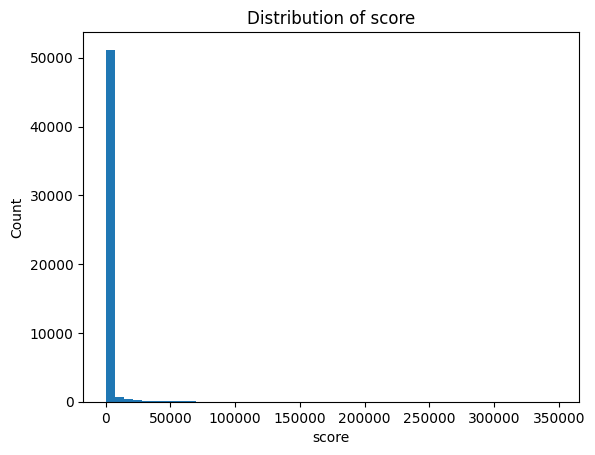

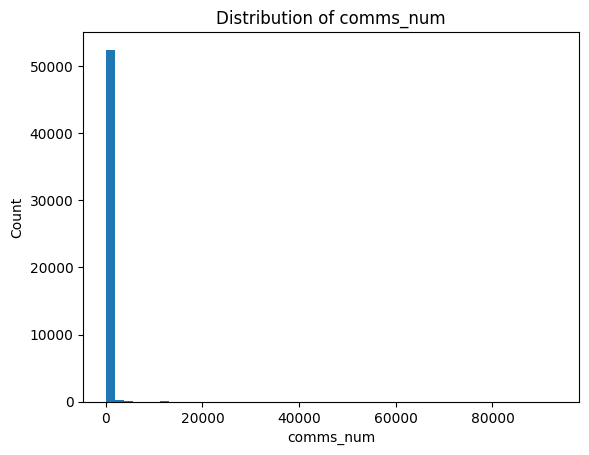

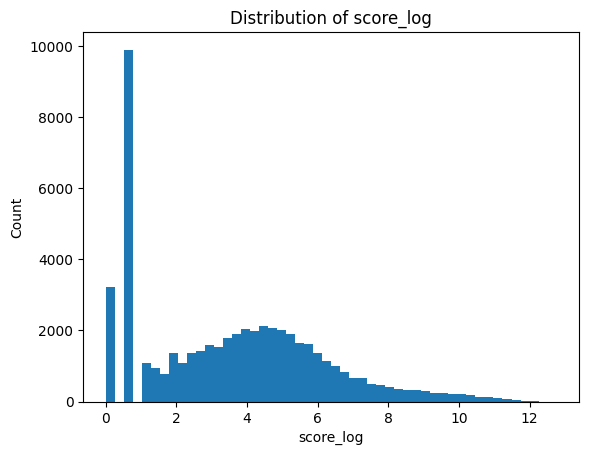

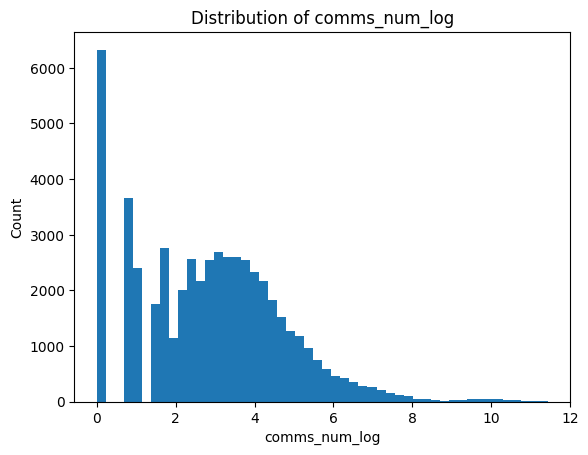

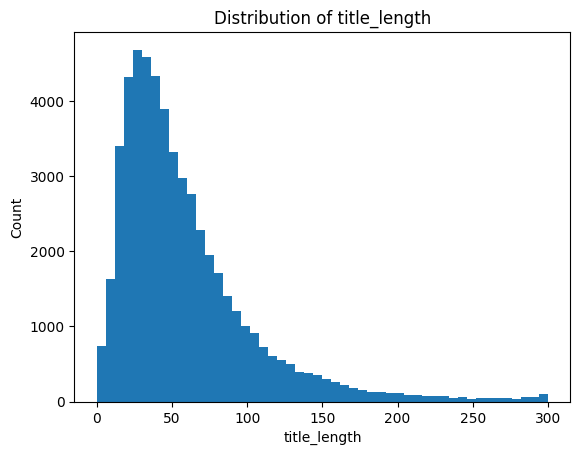

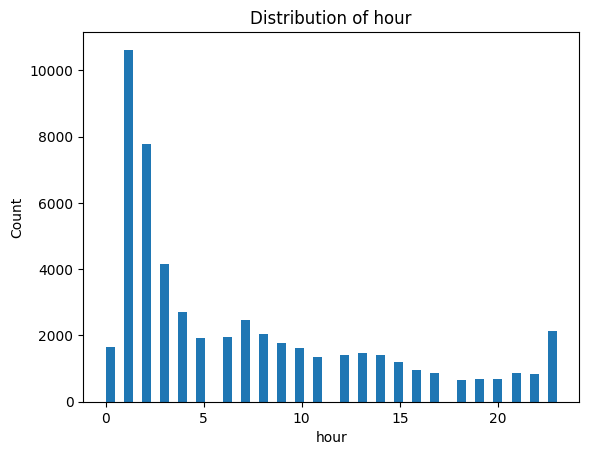

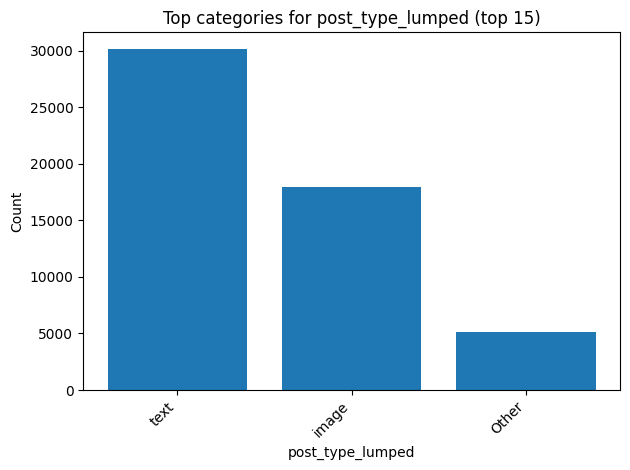

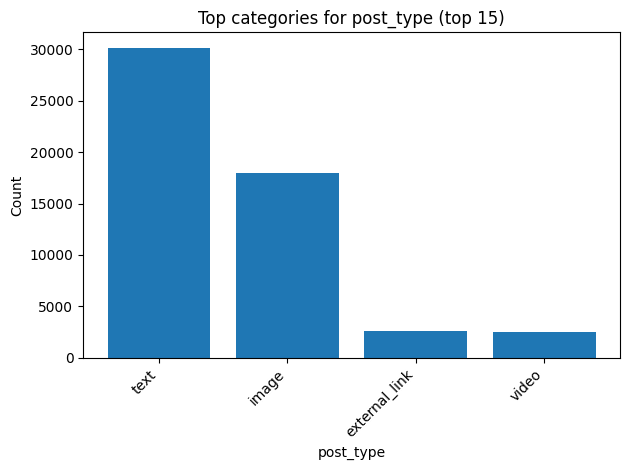

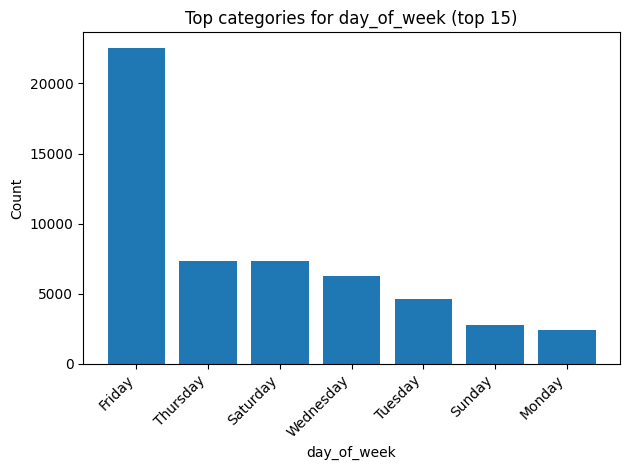

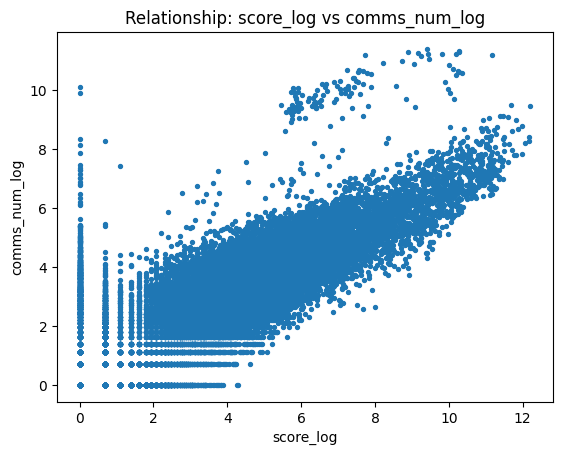

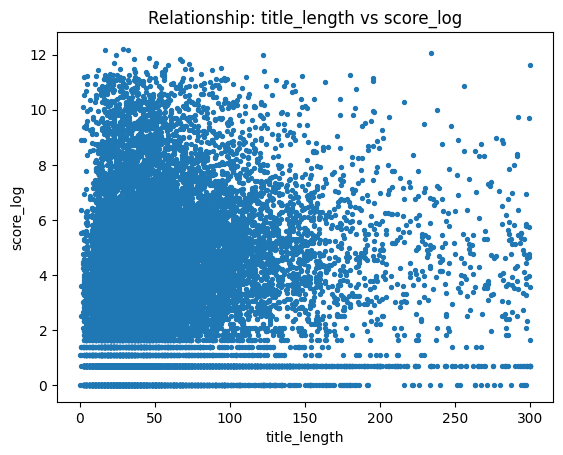

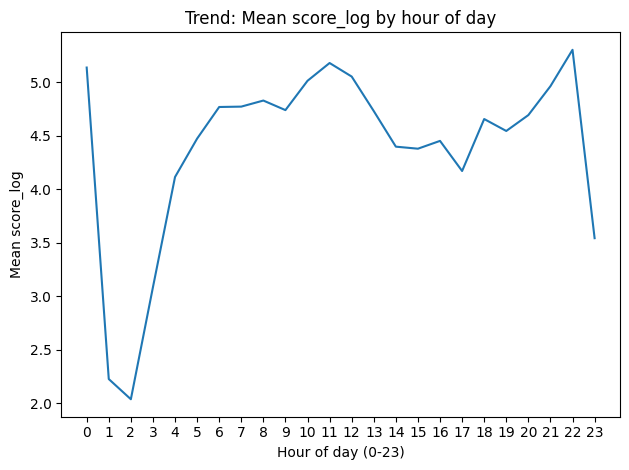

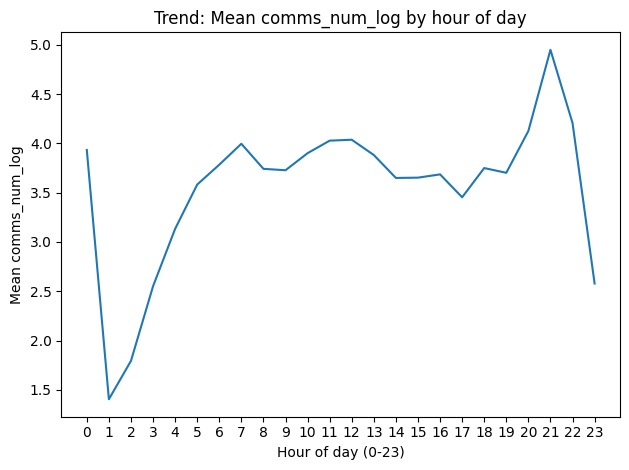

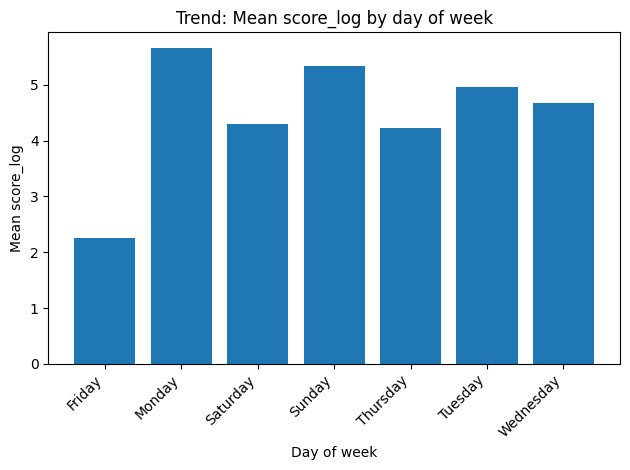

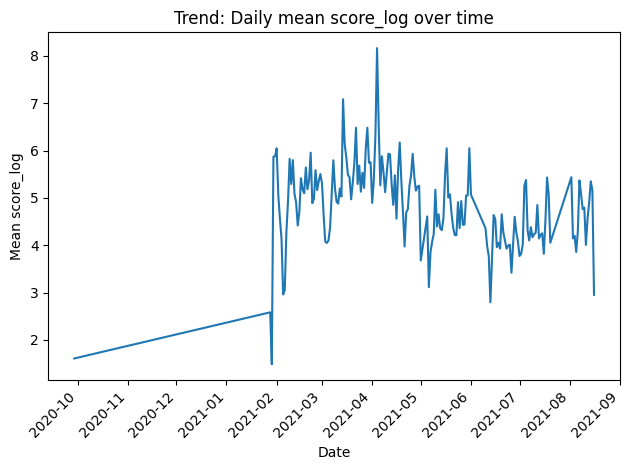

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# EDA Part 2: Visualize distributions, relationships, and trends

# ---------- Helper: safe histogram ----------
def plot_hist(series, title, bins=50, xlabel=None):
    s = series.dropna()
    if len(s) == 0:
        print(f"Skip '{title}' (no non-missing values).")
        return
    plt.figure()
    plt.hist(s, bins=bins)
    plt.title(title)
    plt.xlabel(xlabel if xlabel else series.name)
    plt.ylabel("Count")
    plt.show()

# ---------- Helper: safe scatter ----------
def plot_scatter(x, y, title, xlabel=None, ylabel=None, sample_n=20000):
    df_xy = pd.DataFrame({"x": x, "y": y}).dropna()
    if len(df_xy) == 0:
        print(f"Skip '{title}' (no paired non-missing values).")
        return
    if len(df_xy) > sample_n:
        df_xy = df_xy.sample(sample_n, random_state=42)
    plt.figure()
    plt.scatter(df_xy["x"], df_xy["y"], s=8)
    plt.title(title)
    plt.xlabel(xlabel if xlabel else x.name)
    plt.ylabel(ylabel if ylabel else y.name)
    plt.show()

# ---------- 2.1 Distributions (numeric) ----------
numeric_to_plot = ["score", "comms_num", "score_log", "comms_num_log", "title_length", "hour"]
numeric_to_plot = [c for c in numeric_to_plot if c in df.columns]

for c in numeric_to_plot:
    plot_hist(df[c], title=f"Distribution of {c}", bins=50, xlabel=c)

# ---------- 2.2 Distributions (categorical) ----------
cat_to_plot = ["post_type_lumped", "post_type", "day_of_week"]
cat_to_plot = [c for c in cat_to_plot if c in df.columns]

for c in cat_to_plot:
    vc = df[c].value_counts(dropna=False).head(15)
    plt.figure()
    plt.bar(vc.index.astype(str), vc.values)
    plt.title(f"Top categories for {c} (top 15)")
    plt.xlabel(c)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# ---------- 2.3 Relationships (scatter/correlation-like visuals) ----------
# Typical relationship: score_log vs comms_num_log
if "score_log" in df.columns and "comms_num_log" in df.columns:
    plot_scatter(
        df["score_log"],
        df["comms_num_log"],
        title="Relationship: score_log vs comms_num_log",
        xlabel="score_log",
        ylabel="comms_num_log"
    )

# Relationship: title_length vs score_log (optional)
if "title_length" in df.columns and "score_log" in df.columns:
    plot_scatter(
        df["title_length"],
        df["score_log"],
        title="Relationship: title_length vs score_log",
        xlabel="title_length",
        ylabel="score_log"
    )

# ---------- 2.4 Trends over time-like features ----------
# Trend by hour: mean score_log (and/or comms_num_log)
if "hour" in df.columns:
    if "score_log" in df.columns:
        hour_mean = df.groupby("hour")["score_log"].mean()
        plt.figure()
        plt.plot(hour_mean.index, hour_mean.values)
        plt.title("Trend: Mean score_log by hour of day")
        plt.xlabel("Hour of day (0-23)")
        plt.ylabel("Mean score_log")
        plt.xticks(range(0, 24))
        plt.tight_layout()
        plt.show()

    if "comms_num_log" in df.columns:
        hour_mean_c = df.groupby("hour")["comms_num_log"].mean()
        plt.figure()
        plt.plot(hour_mean_c.index, hour_mean_c.values)
        plt.title("Trend: Mean comms_num_log by hour of day")
        plt.xlabel("Hour of day (0-23)")
        plt.ylabel("Mean comms_num_log")
        plt.xticks(range(0, 24))
        plt.tight_layout()
        plt.show()

# Trend by day_of_week: mean score_log
if "day_of_week" in df.columns and "score_log" in df.columns:
    dow_mean = df.groupby("day_of_week")["score_log"].mean()
    plt.figure()
    plt.bar(dow_mean.index.astype(str), dow_mean.values)
    plt.title("Trend: Mean score_log by day of week")
    plt.xlabel("Day of week")
    plt.ylabel("Mean score_log")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# ---------- 2.5 Trend over date (if you have a 'date' column) ----------
# Note: This assumes df['date'] is parseable as datetime.
if "date" in df.columns and "score_log" in df.columns:
    temp = df[["date", "score_log"]].dropna().copy()
    temp["date"] = pd.to_datetime(temp["date"], errors="coerce")
    temp = temp.dropna(subset=["date"])
    if len(temp) > 0:
        daily_mean = temp.groupby(temp["date"].dt.date)["score_log"].mean()
        plt.figure()
        plt.plot(pd.to_datetime(daily_mean.index), daily_mean.values)
        plt.title("Trend: Daily mean score_log over time")
        plt.xlabel("Date")
        plt.ylabel("Mean score_log")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()


Identify patterns, correlations, anomalies

Top positive correlations with 'score_log':


score_log_zscore        1.000000
score_log               1.000000
score_log_minmax        1.000000
comms_num_log_zscore    0.802039
comms_num_log           0.802039
comms_num_log_minmax    0.802039
score                   0.423924
hour                    0.281764
hour_minmax             0.281764
hour_zscore             0.281764
comms_num               0.176105
title_length            0.084600
title_length_zscore     0.084600
title_length_minmax     0.084600
day_of_week_encoded    -0.204976
Name: score_log, dtype: float64


Top negative correlations with 'score_log':


score_log               1.000000
score_log_minmax        1.000000
comms_num_log_zscore    0.802039
comms_num_log           0.802039
comms_num_log_minmax    0.802039
score                   0.423924
hour                    0.281764
hour_minmax             0.281764
hour_zscore             0.281764
comms_num               0.176105
title_length            0.084600
title_length_zscore     0.084600
title_length_minmax     0.084600
day_of_week_encoded    -0.204976
has_body               -0.242629
Name: score_log, dtype: float64

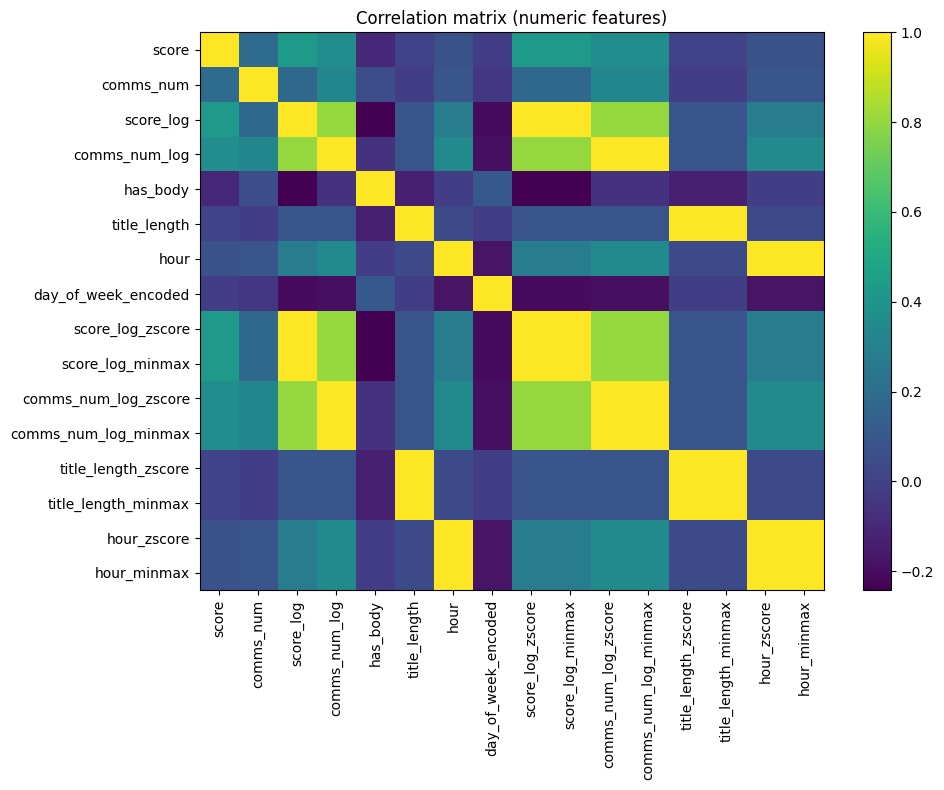


=== Group patterns: score_log by post_type_lumped ===


,count,mean,median,q1,q3,iqr
post_type_lumped,,,,,,
text,30130,2.921554,2.564949,0.693147,4.615121,3.921973
image,17945,4.363144,4.430817,2.890372,5.710427,2.820055
Other,5112,5.377794,5.347108,3.465736,7.332533,3.866797



=== Group patterns: comms_num_log by post_type_lumped ===


,count,mean,median,q1,q3,iqr
post_type_lumped,,,,,,
text,30130,2.632481,2.564949,1.098612,3.951244,2.852631
image,17945,3.077492,3.091042,2.079442,4.110874,2.031432
Other,5112,3.611277,3.610918,2.397895,4.875197,2.477302



=== Group patterns: score by post_type_lumped ===


...

,id,date,title,post_type_lumped,score,comms_num,title_length,url
10189,l7143a,2021-01-29,This is not WSB selling. It wouldn't make a BL...,text,1,5,300,https://www.reddit.com/r/wallstreetbets/commen...
10158,l714id,2021-01-29,Canadian Mom checking in. Yes I am a reddit lu...,text,1,3,300,https://www.reddit.com/r/wallstreetbets/commen...
8028,l70fn5,2021-01-29,Are These Jumps in Price due to Shorts Coverin...,text,1,2,300,https://www.reddit.com/r/wallstreetbets/commen...
18653,l94hdi,2021-01-31,"DFV: ""I think if you want a REAL short squeeze...",Other,1305,392,300,https://streamable.com/6r2w4y
18218,l89alf,2021-01-30,"Huge shoutout to Kevin O'Leary: ""Definition of...",image,111591,3467,300,https://i.redd.it/yfqegtw58de61.png
5321,l6zk9y,2021-01-29,Lets goooooooooooooooooo guys I want AMC getti...,text,4,1,300,https://www.reddit.com/r/wallstreetbets/commen...
23799,lb9zap,2021-02-03,Long time Value 🇬🇧🌈🐻 and lurker reporting in. ...,image,81,5,300,https://i.redd.it/qhqb0ln7h5f61.jpg
44498,mko4sh,2021-04-06,$ASO: I know this is a casino and I know how m...,image,306,128,300,https://i.redd.it/6jq4hgilodr61.png
40357,m27lkm,2021-03-11,Lol cnbc been salty as hell lately seeing gme ...,image,103,34,300,https://i.redd.it/gxp2ewy6g9m61.jpg
11298,l71pv2,2021-01-29,YESTERDAY WAS A BATTLE BUT ROBINHOOD AND THE S...,text,1,0,300,https://www.reddit.com/r/wallstreetbets/commen...



Top 10 posts by score:


,id,date,title,score,comms_num,post_type_lumped,url
19162,l8rf4k,2021-01-31,Times Square right now,348241,11554,Other,https://v.redd.it/x64z70f7eie61
16009,l78uct,2021-01-29,GME YOLO update — Jan 28 2021,225870,23309,image,https://i.redd.it/opzucppb15e61.png
17771,l846a1,2021-01-30,GME YOLO month-end update — Jan 2021,219779,20105,image,https://i.redd.it/r557em3t5ce61.png
34179,lnqgz8,2021-02-20,GME YOLO update — Feb 19 2021,201168,12846,image,https://i.redd.it/2xswz0h11ii61.png
18273,l881ia,2021-01-30,It’s treason then,195782,4523,image,https://i.redd.it/d3t66lv1yce61.jpg
18069,l8c0u4,2021-01-30,Used some of my GME tendies to buy Nintendo Sw...,192980,6785,Other,https://www.nbcdfw.com/news/local/north-texas-...
32168,lexy8t,2021-02-08,Wow super bowl commercial for us,191380,3849,image,https://i.redd.it/tko5nh1qy4g61.jpg
18230,l890i7,2021-01-30,That’s what I thought,175665,4603,image,https://i.redd.it/f2yhugwt5de61.jpg
16220,l7feld,2021-01-29,IT'S POWER TO THE TRADERS NOW,174401,5211,Other,https://v.redd.it/lu8aekujd6e61
18826,l90oq6,2021-01-31,I am proud to do my part in paying forward our...,171778,3633,image,https://i.redd.it/sgrbt9vthke61.jpg



Top 10 posts by number of comments (comms_num):


,id,date,title,score,comms_num,post_type_lumped,url
39993,m1xhlc,2021-03-10,"GME Megathread for March 10, 2021",47667,93268,text,https://www.reddit.com/r/wallstreetbets/commen...
17095,l7ptxi,2021-01-29,"Daily Discussion Thread for January 29, 2021",12288,89050,text,https://www.reddit.com/r/wallstreetbets/commen...
35110,lre2k6,2021-02-25,"GME Megathread for Wednesday, February 24th, 2021",28975,83094,text,https://www.reddit.com/r/wallstreetbets/commen...
17249,l7wqsm,2021-01-30,"Daily Discussion Thread for January 29, 2021 -...",7348,80926,text,https://www.reddit.com/r/wallstreetbets/commen...
17313,l7v9o8,2021-01-30,GME What About Second Breakfast Club Megathread,29356,80586,text,https://www.reddit.com/r/wallstreetbets/commen...
17011,l7s631,2021-01-29,GME Breakfast Club Megathread,25561,77167,text,https://www.reddit.com/r/wallstreetbets/commen...
38903,m0fpgd,2021-03-08,"GME Megathread for March 08, 2021",30653,77080,text,https://www.reddit.com/r/wallstreetbets/commen...
16027,l78za1,2021-01-29,"Daily Discussion Thread Part 5 for January 28,...",9549,75976,text,https://www.reddit.com/r/wallstreetbets/commen...
35524,ls63oa,2021-02-25,"GME Megathread for Thursday February 25th, 2021",31809,75839,text,https://www.reddit.com/r/wallstreetbets/commen...
33818,lm7n51,2021-02-18,Congressional hearings / DFV / GME / etc megat...,12522,75382,text,https://www.reddit.com/r/wallstreetbets/commen...


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# EDA Part 3: Identify patterns, correlations, and anomalies
# ---------- 3.1 Correlations (numeric) ----------
# Select numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Optionally drop obvious ID-like numeric fields if they exist (keep only meaningful signals)
drop_candidates = ["timestamp"]  # timestamp can dominate correlations but isn't very informative for EDA
numeric_cols = [c for c in numeric_cols if c not in drop_candidates]

if len(numeric_cols) >= 2:
    corr = df[numeric_cols].corr(numeric_only=True)

    # Display top correlations with a target (prefer score_log if available)
    target = "score_log" if "score_log" in corr.columns else (numeric_cols[0] if numeric_cols else None)

    if target:
        corr_target = corr[target].dropna().sort_values(ascending=False)
        print(f"Top positive correlations with '{target}':")
        display(corr_target.head(15))

        print(f"\nTop negative correlations with '{target}':")
        display(corr_target.tail(15))

    # Optional: correlation heatmap (matplotlib only)
    plt.figure(figsize=(10, 8))
    plt.imshow(corr, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title("Correlation matrix (numeric features)")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns to compute correlations.")

# ---------- 3.2 Patterns by groups (post type / day of week / has_body) ----------
# Compare engagement by categories using robust summaries (median + IQR)
group_candidates = ["post_type_lumped", "post_type", "day_of_week", "has_body", "type_image", "type_text"]
group_candidates = [c for c in group_candidates if c in df.columns]

metric_candidates = ["score_log", "comms_num_log", "score", "comms_num"]
metric_candidates = [c for c in metric_candidates if c in df.columns]

def group_summary(df, group_col, metric_col):
    g = df.groupby(group_col)[metric_col]
    out = g.agg(
        count="count",
        mean="mean",
        median="median",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    ).sort_values("count", ascending=False)
    out["iqr"] = out["q3"] - out["q1"]
    return out

for gcol in group_candidates:
    for mcol in metric_candidates:
        print(f"\n=== Group patterns: {mcol} by {gcol} ===")
        summary = group_summary(df.dropna(subset=[gcol, mcol]), gcol, mcol)
        display(summary.head(15))

# ---------- 3.3 Anomalies / outliers ----------
# Strategy A: Use z-score columns if available (|z| >= 3)
z_cols = [c for c in ["score_log_zscore", "comms_num_log_zscore", "title_length_zscore", "hour_zscore"] if c in df.columns]

for z in z_cols:
    anomalies = df[df[z].abs() >= 3].copy()
    pct = len(anomalies) / len(df) * 100
    print(f"\nOutliers based on {z}: {len(anomalies)} rows ({pct:.2f}% of the dataset) with |z| >= 3")

    # Show a compact view of extreme cases
    show_cols = [c for c in ["id", "date", "title", "post_type_lumped", "score", "comms_num", z, "url"] if c in anomalies.columns]
    display(anomalies[show_cols].head(10))

# Strategy B: IQR-based outliers for key metrics (works even without z-score columns)
def iqr_bounds(series, k=1.5):
    s = series.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

iqr_metrics = [c for c in ["score_log", "comms_num_log", "title_length"] if c in df.columns]
for col in iqr_metrics:
    low, high = iqr_bounds(df[col])
    mask = (df[col] < low) | (df[col] > high)
    out_n = int(mask.sum())
    print(f"\nIQR outliers for {col}: {out_n} rows | bounds ~ [{low:.3f}, {high:.3f}]")

    if out_n > 0:
        extremes = df.loc[mask].copy()
        extremes["abs_dev_from_median"] = (extremes[col] - df[col].median()).abs()
        extremes = extremes.sort_values("abs_dev_from_median", ascending=False).head(10)

        show_cols = [c for c in ["id", "date", "title", "post_type_lumped", "score", "comms_num", col, "url"] if c in extremes.columns]
        display(extremes[show_cols])

# ---------- 3.4 Inspect top extreme posts (high score / high comments) ----------
if "score" in df.columns:
    print("\nTop 10 posts by score:")
    top_score = df.sort_values("score", ascending=False).head(10)
    show_cols = [c for c in ["id", "date", "title", "score", "comms_num", "post_type_lumped", "url"] if c in top_score.columns]
    display(top_score[show_cols])

if "comms_num" in df.columns:
    print("\nTop 10 posts by number of comments (comms_num):")
    top_comments = df.sort_values("comms_num", ascending=False).head(10)
    show_cols = [c for c in ["id", "date", "title", "score", "comms_num", "post_type_lumped", "url"] if c in top_comments.columns]
    display(top_comments[show_cols])


Provide initial interpretations of data insights

In [ ]:
import pandas as pd
import numpy as np

# EDA Part 4: Provide initial interpretations of data insights

insights = []

# 4.1 Dataset size
insights.append(f"The cleaned dataset contains {df.shape[0]:,} rows and {df.shape[1]} columns.")

# 4.2 Missingness summary
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
top_missing = missing_pct[missing_pct > 0].head(5)

if len(top_missing) > 0:
    miss_text = ", ".join([f"{col}={pct:.1f}%" for col, pct in top_missing.items()])
    insights.append(f"Missingness is concentrated in the following columns: {miss_text}.")
else:
    insights.append("No missing values were detected in the current dataframe.")

# 4.3 Core correlation: score_log vs comms_num_log
if "score_log" in df.columns and "comms_num_log" in df.columns:
    corr_sc = df[["score_log", "comms_num_log"]].corr(numeric_only=True).iloc[0, 1]
    insights.append(
        f"`score_log` and `comms_num_log` show a strong positive association (correlation r = {corr_sc:.3f}), "
        "suggesting that posts with higher scores tend to also receive more comments."
    )

# 4.4 Posting time effect (hour)
if "hour" in df.columns and "score_log" in df.columns:
    hour_mean = df.groupby("hour")["score_log"].mean()
    best_hour = int(hour_mean.idxmax())
    worst_hour = int(hour_mean.idxmin())
    insights.append(
        f"Posting time appears to matter: mean `score_log` peaks around hour {best_hour} and is lowest around hour {worst_hour} "
        "(based on average `score_log` by hour)."
    )

# 4.5 Differences by post type (use lumped type if available)
type_col = "post_type_lumped" if "post_type_lumped" in df.columns else ("post_type" if "post_type" in df.columns else None)
if type_col and "score_log" in df.columns:
    type_stats = df.groupby(type_col)["score_log"].agg(["count", "median"]).sort_values("count", ascending=False)
    top_types = type_stats.head(5)

    if len(top_types) > 0:
        parts = []
        for idx, row in top_types.iterrows():
            parts.append(f"{idx} (n={int(row['count'])}, median={row['median']:.2f})")
        insights.append(
            f"Engagement differs by post type: the most frequent categories and their median `score_log` are "
            + ", ".join(parts) + "."
        )

# 4.6 Outliers (z-score based) if available
if "score_log_zscore" in df.columns:
    out_pct = (df["score_log_zscore"].abs() >= 3).mean() * 100
    insights.append(
        f"Outliers are relatively rare: approximately {out_pct:.2f}% of posts have |`score_log_zscore`| ≥ 3, "
        "consistent with a small set of viral/extreme posts driving a heavy-tailed distribution."
    )

# 4.7 Title length effect (optional, simple check)
if "title_length" in df.columns and "score_log" in df.columns:
    corr_tl = df[["title_length", "score_log"]].corr(numeric_only=True).iloc[0, 1]
    insights.append(
        f"The correlation between `title_length` and `score_log` is {corr_tl:.3f}, "
        "which provides an initial indication of whether longer titles are associated with higher engagement."
    )

# Print the final interpretations
print("=== Initial interpretations (EDA) ===")
for i, text in enumerate(insights, 1):
    print(f"{i}. {text}")


=== Initial interpretations (EDA) ===
1. The cleaned dataset contains 53,187 rows and 30 columns.
2. Missingness is concentrated in the following columns: body_clean=53.6%, body=53.5%, title_nlp=0.1%, title_clean=0.0%.
3. `score_log` and `comms_num_log` show a strong positive association (correlation r = 0.802), suggesting that posts with higher scores tend to also receive more comments.
4. Posting time appears to matter: mean `score_log` peaks around hour 22 and is lowest around hour 2 (based on average `score_log` by hour).
5. Engagement differs by post type: the most frequent categories and their median `score_log` are text (n=30130, median=2.56), image (n=17945, median=4.43), Other (n=5112, median=5.35).
6. Outliers are relatively rare: approximately 0.17% of posts have |`score_log_zscore`| ≥ 3, consistent with a small set of viral/extreme posts driving a heavy-tailed distribution.
7. The correlation between `title_length` and `score_log` is 0.085, which provides an initial indicat

=== Initial interpretations (EDA) ===
1. The cleaned dataset contains 53,187 rows and 30 columns.
2. Missingness is concentrated in the following columns: body_clean=53.6%, body=53.5%, title_nlp=0.1%, title_clean=0.0%.
3. `score_log` and `comms_num_log` show a strong positive association (correlation r = 0.802), suggesting that posts with higher scores tend to also receive more comments.
4. Posting time appears to matter: mean `score_log` peaks around hour 22 and is lowest around hour 2 (based on average `score_log` by hour).
5. Engagement differs by post type: the most frequent categories and their median `score_log` are text (n=30130, median=2.56), image (n=17945, median=4.43), Other (n=5112, median=5.35).
6. Outliers are relatively rare: approximately 0.17% of posts have |`score_log_zscore`| ≥ 3, consistent with a small set of viral/extreme posts driving a heavy-tailed distribution.
7. The correlation between `title_length` and `score_log` is 0.085, which provides an initial indication of whether longer titles are associated with higher engagement.